# Life Expectancy Prediction: EDA and Model Design

## Intro

Life expectancy is a statistical measurement used to estimate an individual's lifespan. On an individual level, life expectancy is crucial in determining one's plans, support and care. On a larger group level, it holds paramount socio-economical implications. On a country level, it is used to derive insights, analytics and further studies to better understand the needs & risk factors of populations.

## Aim

One of the main focuses of this project is data integrity. Several countries have previously expressed concerns with sharing some of their sensitive data, such as medical records, as they brought about unwanted financial implications when correlated with their quality of life measurements and hindered social developments.

The team has been tasked with constructing two models: 

>* One that uses the least information necessary to make a prediction 
>
>* Another which may include sensitive health features which can be used if states decide to share more sensitive data.

Another team has managed to produce a semi-robust model with a RMSE of 1.8 years, so this will be considered a baseline which we will aim to beat to secure further collaboration with the WHO.

---

The dataset to be used for model training has been provided by the World Health Organization (WHO). This data contains 179 countries, with associated demographic, socio-economic and health related features - described by the data dictionary below.

## Data Dictionary

|Field|Description|
|---:|:---|
|Country|Country|
|Year|Year|
|Economy Status|Developed or Developing status|
|Life expectancy|Life Expectancy in age|
|Adult Mortality|Adult Mortality Rates of both sexes (probability of dying between 15 and 60 years per 1000 population)|
|Infant deaths|Number of Infant Deaths per 1000 population|
|Alcohol|Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)|
|Hepatitis B|Hepatitis B (HepB) immunization coverage among 1-year-olds (%)|
|Measles|Measles - number of reported cases per 1000 population|
|BMI|Average Body Mass Index of entire population|
|Under-five deaths|Number of under-five deaths per 1000 population|
|Polio|Polio (Pol3) immunization coverage among 1-year-olds (%)|
|Diphtheria|Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)|
|HIV Incidents|Deaths per 1 000 live births HIV/AIDS (0-4 years)|
|GDP|Gross Domestic Product per capita (in USD)|
|Population|Population of the country (millions)|
|Thinness 1-19 years|Prevalence of thinness among children and adolescents for Age 10 to 19 (%)|
|Thinness 5-9 years|Prevalence of thinness among children for Age 5 to 9 (%)|
|Schooling|Number of years of Schooling (years)|

## Loading the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import pydantic
pd.options.display.max_columns = None

We use the WHO colour palette (blue, gold) across the charts below for visual consistency

In [2]:
WHO_BLUE = '#009EDB'
WHO_GOLD = '#FD9D24'
WHO_WHITE = '#FFFFFF'

In [3]:
data = pd.read_csv('Life Expectancy Data.csv')
data.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   str    
 1   Region                       2864 non-null   str    
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita               

Checking the general structure and completeness of the data. Making sure there are no nulls etc.

In [5]:
data.shape

(2864, 21)

In [6]:
print("missing values per column:")
print(data.isnull().sum())
print()
print("duplicate rows:", data.duplicated().sum())
print()
data.describe().T

missing values per column:
Country                        0
Region                         0
Year                           0
Infant_deaths                  0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Population_mln                 0
Thinness_ten_nineteen_years    0
Thinness_five_nine_years       0
Schooling                      0
Economy_status_Developed       0
Economy_status_Developing      0
Life_expectancy                0
dtype: int64

duplicate rows: 0



,count,mean,std,min,25%,50%,75%,max
Year,2864.0,2007.500000,4.610577,2000.000,2003.75000,2007.5000,2011.250000,2015.0000
Infant_deaths,2864.0,30.363792,27.538117,1.800,8.10000,19.6000,47.350000,138.1000
Under_five_deaths,2864.0,42.938268,44.569974,2.300,9.67500,23.1000,66.000000,224.9000
Adult_mortality,2864.0,192.251775,114.910281,49.384,106.91025,163.8415,246.791375,719.3605
Alcohol_consumption,2864.0,4.820882,3.981949,0.000,1.20000,4.0200,7.777500,17.8700
Hepatitis_B,2864.0,84.292598,15.995511,12.000,78.00000,89.0000,96.000000,99.0000
Measles,2864.0,77.344972,18.659693,10.000,64.00000,83.0000,93.000000,99.0000
BMI,2864.0,25.032926,2.193905,19.800,23.20000,25.5000,26.400000,32.1000
Polio,2864.0,86.499651,15.080365,8.000,81.00000,93.0000,97.000000,99.0000
Diphtheria,2864.0,86.271648,15.534225,16.000,81.00000,93.0000,97.000000,99.0000


No missing values and no duplicate rows. the ranges in `describe()` also look plausible, no negative values or out-of-range percentages in the immunisation columns.

## EDA

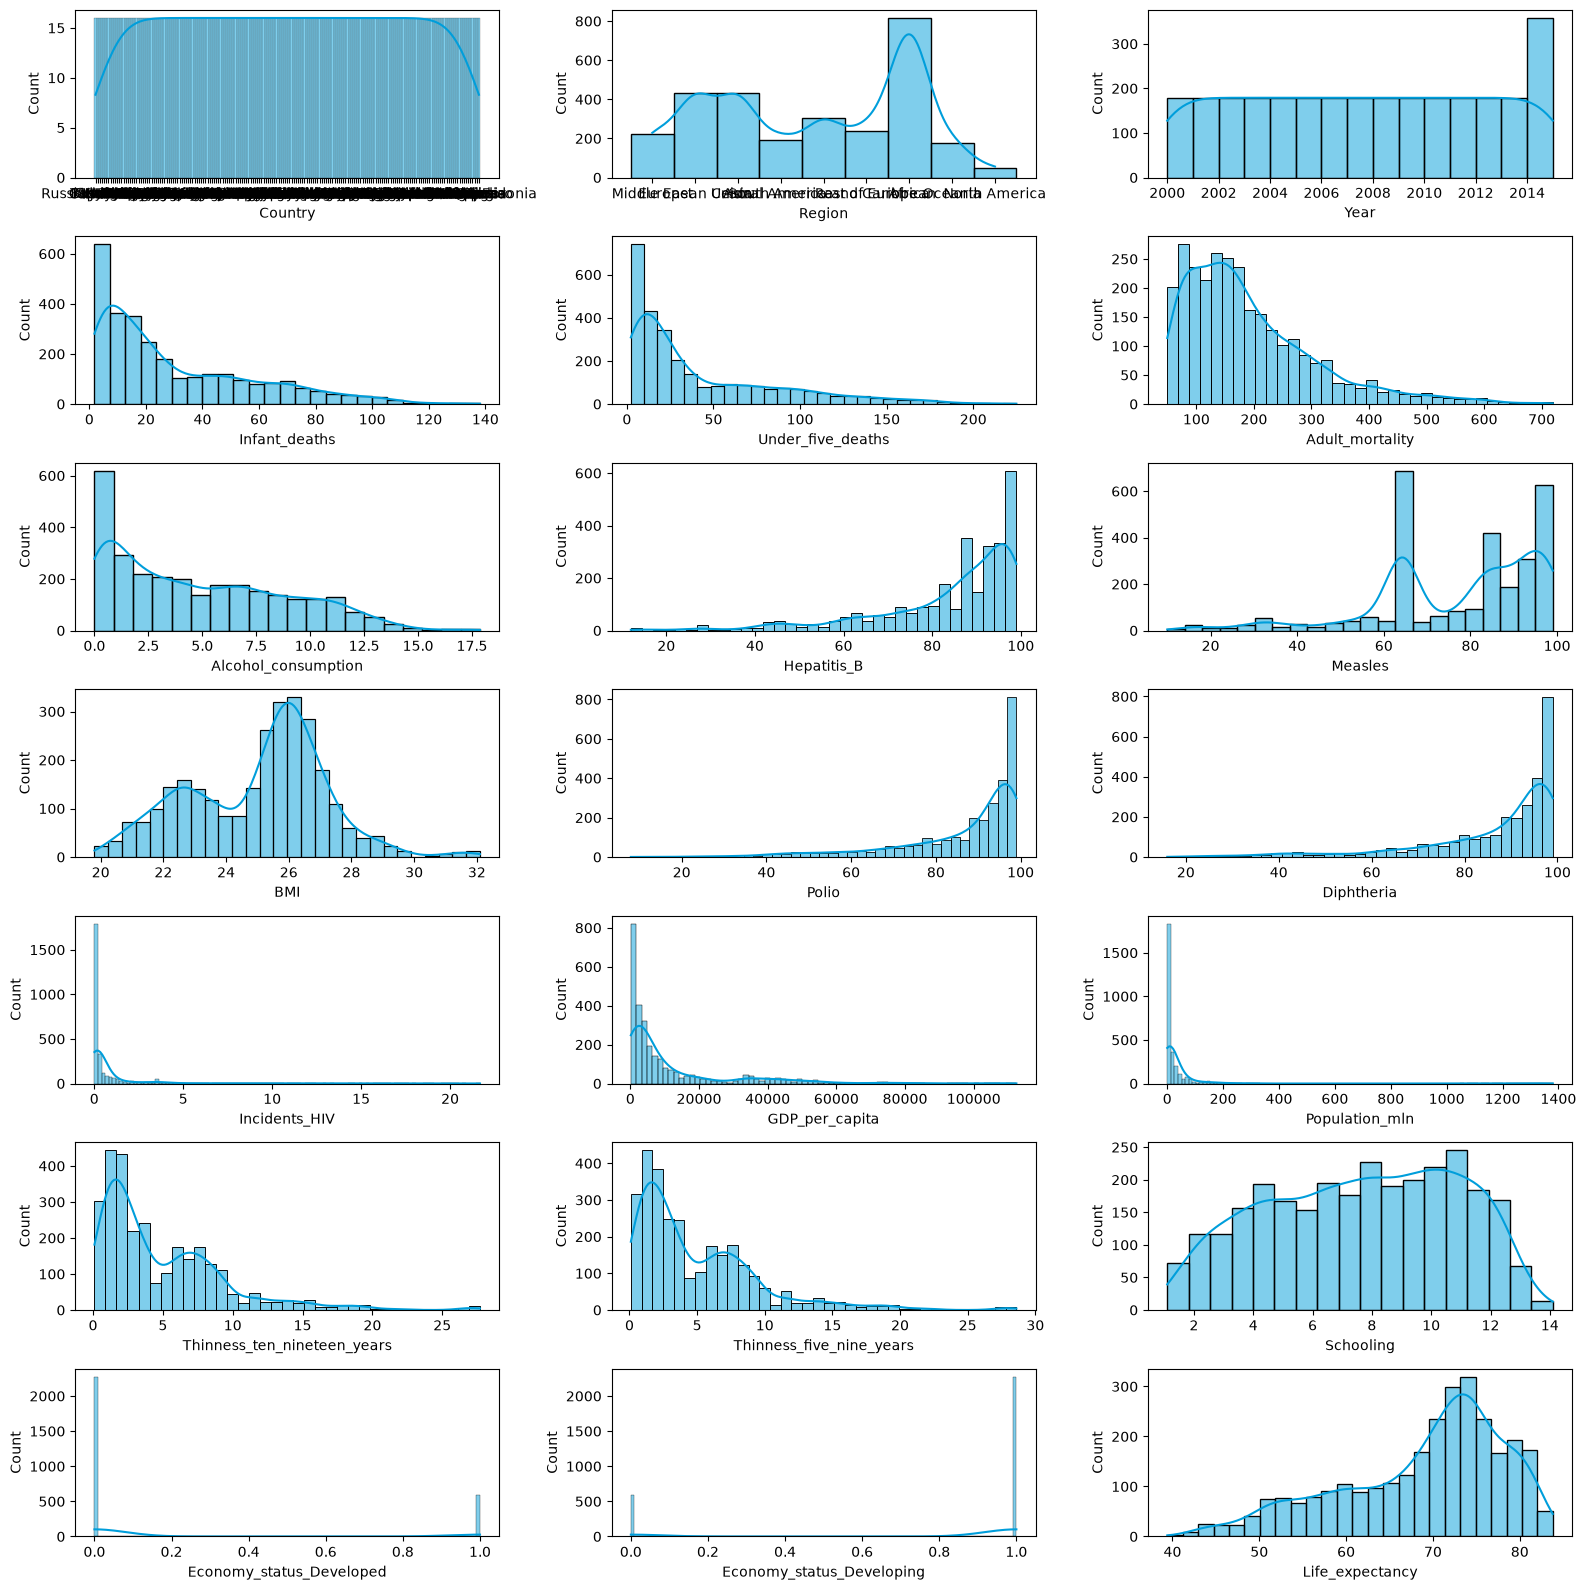

In [7]:
plt.figure(figsize=(16,16))
for index, column in enumerate(data.columns):
  plt.subplot(7,3,index+1)
  sns.histplot(data=data, x=column, kde=True, color=WHO_BLUE)

plt.tight_layout()
plt.show()

Exploring the individial columns to find the general trend for each of the features.

### Further Quality and Pattern Checks

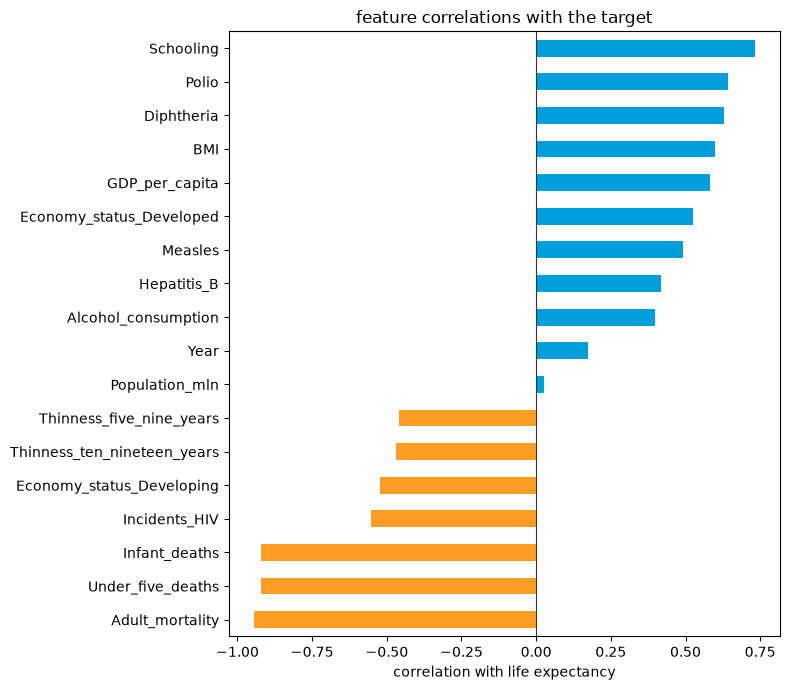

In [8]:
corr_with_target = data.corr(numeric_only=True)['Life_expectancy'].drop('Life_expectancy').sort_values()

plt.figure(figsize=(8, 7))
colors = [WHO_GOLD if v < 0 else WHO_BLUE for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='#333333', linewidth=0.8)
plt.xlabel('correlation with life expectancy')
plt.title('feature correlations with the target')
plt.tight_layout()
plt.show()

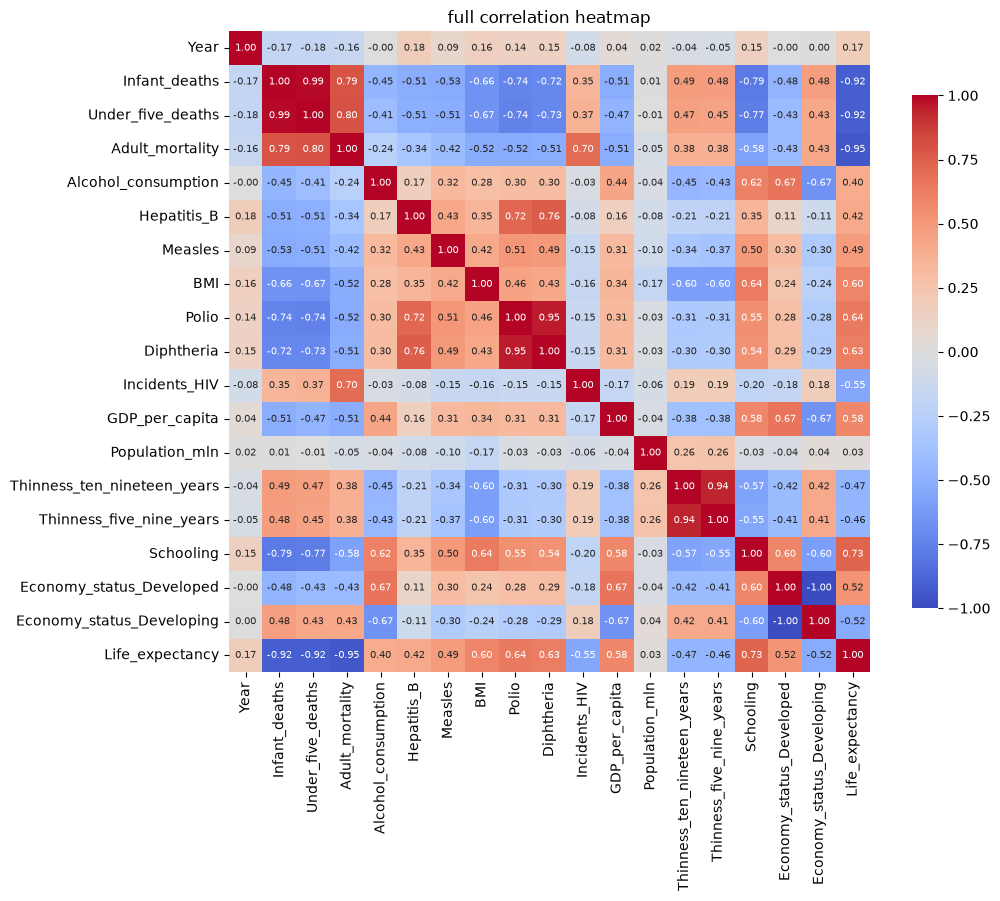

In [9]:
plt.figure(figsize=(11, 9))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
plt.title('full correlation heatmap')
plt.tight_layout()
plt.show()

Strongest predictors are `Adult_mortality`, `Under_five_deaths`, and `Infant_deaths` (all around -0.92 to -0.95), the heatmap also confirms `Infant_deaths`/`Under_five_deaths` are near-perfectly correlated, which is what motivated the collinearity fix below.

### Investigating the `Measles` spike

The distribution grid above shows an unusual spike in `Measles` around a single value. Worth checking whether this is a genuine pattern or a placeholder.

In [10]:
spike = data[(data['Measles'] >= 60) & (data['Measles'] < 70)]
print(spike['Measles'].value_counts().sort_index())

exact_64 = data[data['Measles'] == 64]
print()
print('rows with Measles == 64 exactly:', len(exact_64))
print('unique countries:', exact_64['Country'].nunique())
print(exact_64['Region'].value_counts())

Measles
60     21
61      7
62      5
63     21
64    486
65    176
66      4
67      9
68     12
69      6
Name: count, dtype: int64

rows with Measles == 64 exactly: 486
unique countries: 36
Region
Africa                           465
Oceania                           16
European Union                     3
Central America and Caribbean      1
Middle East                        1
Name: count, dtype: int64


30 of the 36 countries involved (mostly African) carry this exact value across all 16 years. Real epidemiological data doesn't stay perfectly constant for 16 straight years ∴ this looks like a placeholder or imputed default rather than a genuine measurement, worth flagging as a data-quality caveat rather than treating it as a real signal.

### GDP and Population: Correcting for Skew

`GDP_per_capita` and `Population_mln` are both strongly right-skewed, with a small number of very large economies or countries pulling the tail of the distribution. A log transform pulls these outliers in and brings the distributions closer to normal, which reduces their leverage on the regression coefficients. 

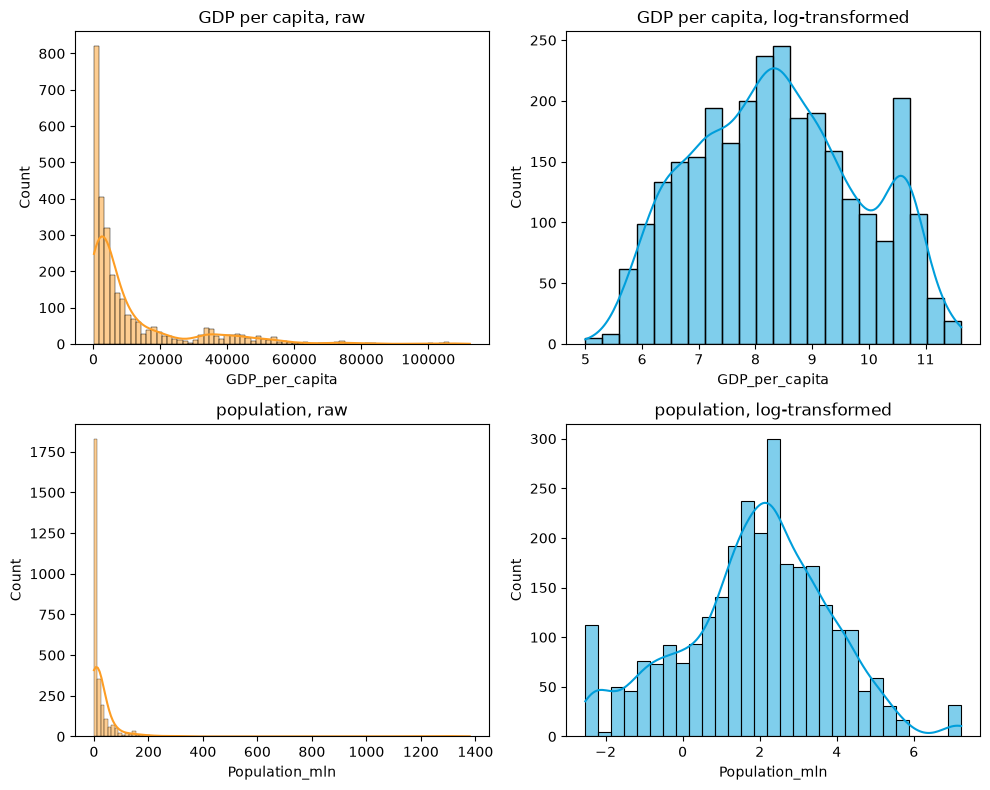

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.histplot(data=data, x='GDP_per_capita', kde=True, ax=axes[0,0], color=WHO_GOLD)
axes[0,0].set_title('GDP per capita, raw')
sns.histplot(x=np.log(data['GDP_per_capita']), kde=True, ax=axes[0,1], color=WHO_BLUE)
axes[0,1].set_title('GDP per capita, log-transformed')
sns.histplot(data=data, x='Population_mln', kde=True, ax=axes[1,0], color=WHO_GOLD)
axes[1,0].set_title('population, raw')
sns.histplot(x=np.log(data['Population_mln']), kde=True, ax=axes[1,1], color=WHO_BLUE)
axes[1,1].set_title('population, log-transformed')
plt.tight_layout()
plt.show()

In [12]:
# log transform important skewed distributions
data['log_GDP'] = np.log(data['GDP_per_capita'])
data['log_Population'] = np.log(data['Population_mln'])
data = data.drop(columns=['GDP_per_capita', 'Population_mln'])

### Infant vs Under-five deaths: Addressing Collinearity

`Infant_deaths` and `Under_five_deaths` are almost perfectly correlated, since under-five deaths include infant deaths by definition. Keeping both raw columns would introduce severe multicollinearity. The scatter plot below confirms the strength of this relationship. To correct for this, we engineer `Child_mortality_1_to_5` (under-five deaths minus infant deaths) and drop `Under_five_deaths`, keeping the two remaining columns independent.

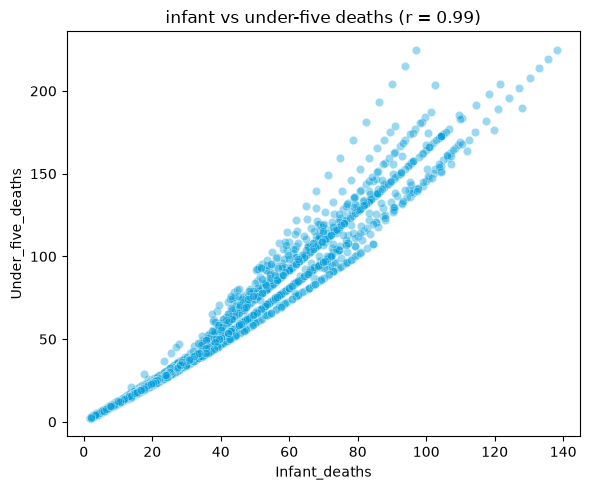

In [13]:
fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=data, x='Infant_deaths', y='Under_five_deaths', alpha=0.4, ax=ax, color=WHO_BLUE)
corr = data['Infant_deaths'].corr(data['Under_five_deaths'])
ax.set_title(f'infant vs under-five deaths (r = {corr:.2f})')
plt.tight_layout()
plt.show()

## VIF Analysis

To investigate potential collinearity between features, we also calculate Variance Inflation Factor. 

**Any values above 5 should be considered as a feature that is a collinearity risk.**

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_cols = [
    'Infant_deaths', 'Under_five_deaths', 'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B',
    'Measles', 'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'log_GDP', 'log_Population',
    'Thinness_ten_nineteen_years', 'Thinness_five_nine_years', 'Schooling',
]

X_vif = add_constant(data[vif_cols].dropna())
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).query("feature != 'const'").sort_values('VIF', ascending=False)

vif_df

,feature,VIF
1,Infant_deaths,45.232286
2,Under_five_deaths,43.185454
9,Diphtheria,13.044212
8,Polio,12.178065
13,Thinness_ten_nineteen_years,8.893888
14,Thinness_five_nine_years,8.892342
3,Adult_mortality,7.787215
11,log_GDP,4.559764
15,Schooling,4.332395
10,Incidents_HIV,3.076697


* `Under_five_deaths`/`Infant_deaths`
* `Diphtheria`/`Polio`
* `Thinness_ten_nineteen`/`Thinness_five_nine`

All show collinearity, which should be considered if these features are included in the model.

In [15]:
# address collinearity by separating infant_deaths from under_five deaths
data['Child_mortality_1_to_5'] = data['Under_five_deaths'] - data['Infant_deaths'] 
data = data.drop(columns=['Under_five_deaths'])

In [16]:
data['Life_expectancy'].unique()

array([76.5, 82.8, 65.4, 67. , 81.7, 78.2, 71.2, 71.9, 68.7, 74.2, 79.8,
       72.3, 68.3, 81.5, 78.8, 81. , 60.7, 81.9, 62.9, 61.4, 68.8, 53.8,
       63.8, 73.5, 66.2, 57.6, 72.8, 48.4, 65.3, 82.2, 73.7, 63.2, 80. ,
       74.5, 64.2, 72.7, 64.3, 82.5, 56.2, 78.6, 60.9, 79.4, 72.1, 70. ,
       72.6, 74.7, 80.2, 76. , 75.8, 48. , 76.1, 65.8, 73.1, 43.1, 71.1,
       57.5, 65.1, 74.8, 66.3, 71.3, 68. , 55.8, 74.6, 61.9, 78.7, 75.9,
       76.4, 76.9, 82.7, 76.2, 53.3, 73.8, 60.6, 52.7, 83.2, 54.6, 67.4,
       50. , 56.7, 65.5, 81.8, 61.2, 43.3, 51.3, 53.4, 66.8, 70.7, 75. ,
       59.3, 69.8, 65.6, 67.5, 63.9, 72.2, 71.6, 82.3, 80.8, 75.1, 75.6,
       75.2, 52.5, 58. , 60.8, 55.4, 53.5, 73. , 68.4, 59.5, 79.5, 74.4,
       66. , 78.1, 69.7, 77.5, 74.3, 51.2, 71. , 78. , 45.1, 79.2, 69.3,
       76.3, 81.2, 44.1, 73.6, 67.3, 48.5, 45.5, 51. , 52.1, 68.6, 47.7,
       74.1, 68.2, 44.6, 72.4, 69.5, 48.3, 63. , 62.3, 75.7, 77.1, 77. ,
       49.8, 46.5, 68.1, 57.1, 82. , 50.6, 69.1, 49

Confirm no placeholder values in target variable.

In [17]:
data['Region'].unique()

<ArrowStringArray>
[                  'Middle East',                'European Union',
                          'Asia',                 'South America',
 'Central America and Caribbean',                'Rest of Europe',
                        'Africa',                       'Oceania',
                 'North America']
Length: 9, dtype: str

Checking the different regions in our dataset

In [18]:
data['Country'].nunique()

179

In [19]:
print("countries:", data['Country'].nunique())
print("year range:", data['Year'].min(), "-", data['Year'].max())
print()
print("records per country:")
print(data.groupby('Country')['Year'].count().describe())

countries: 179
year range: 2000 - 2015

records per country:
count    179.0
mean      16.0
std        0.0
min       16.0
25%       16.0
50%       16.0
75%       16.0
max       16.0
Name: Year, dtype: float64


every country has 16 records with no gaps, 179 countries x 16 years = 2,864 rows, matching the dataset shape confirmed earlier. the panel is balanced, no country is over- or under-represented.

In [20]:
# restrict the simple model (referred to as the insensitive model) to the following feature pool. no sensitive health related features are to be used.
insensitive_df = data[['Country', 
                       'Region', 
                       'Year', 
                       'log_GDP', 
                       'log_Population', 
                       'Schooling', 
                       'Economy_status_Developed', 
                       'Life_expectancy']]

# the elaborate model may draw from the entire feature pool
sensitive_df = data.copy()

'One of the main focuses of this project is data integrity. Several countries have previously expressed concerns with sharing some of their sensitive data, such as medical records, as they brought about unwanted financial implications when correlated with their quality of life measurements and hindered social dvelopments'.

We deemed the list of features above to be in accordance to such requests thus, factors such as alcohol consumptions and adult mortality rate is in the sensitive category. Any disease/ medical conditions are all within the sensitive category as well.

## Train-Test Split

In [21]:
X_insensitive = insensitive_df.drop(columns=['Life_expectancy'])
y_insensitive = insensitive_df['Life_expectancy']

X_sensitive = sensitive_df.drop(columns=['Life_expectancy'])
y_sensitive = sensitive_df['Life_expectancy']

Organising our X and y variables to be ready for our train test split. 

In [22]:
from sklearn.model_selection import train_test_split

X_insensitive_train, X_insensitive_test, y_insensitive_train, y_insensitive_test = train_test_split(X_insensitive, y_insensitive, test_size=0.2, random_state=42, shuffle=True)
X_sensitive_train, X_sensitive_test, y_sensitive_train, y_sensitive_test = train_test_split(X_sensitive, y_sensitive, test_size=0.2, random_state=42, shuffle=True)

An 80:20 train-test split was performed using random state 42 for reproducibility.

In [23]:
X_insensitive_train.shape, y_insensitive_train.shape

((2291, 7), (2291,))

In [24]:
X_sensitive_train.shape, y_sensitive_train.shape

((2291, 20), (2291,))

## Building the Training Pipeline

We begin by identifying and separating the numeric features from the categorical features for both models.

In [25]:
insens_numeric_features = X_insensitive.select_dtypes(
    include=["int64", "float64"]
).columns

insens_categorical_features = X_insensitive.select_dtypes(
    include=["str"]
).columns

insens_categorical_features = insens_categorical_features.drop('Country')

sens_numeric_features = X_sensitive.select_dtypes(
    include=["int64", "float64"]
).columns

sens_categorical_features = X_sensitive.select_dtypes(
    include=["str"]
).columns

sens_categorical_features = sens_categorical_features.drop('Country')

Any numeric features are to be standard scaled to ensure all features are of a comparable magnitude, whilst the categorical features will be one-hot encoded. `drop='first'` is passed to the OneHotEncoder to remove a redundant dummy variable from the model to alleviate multi-collinearity.

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler,
                                   OneHotEncoder)
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

numeric_transformer = Pipeline([        
  ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(drop='first', handle_unknown="ignore"))
])

`ColumnTransformer` stitches the two mini-pipelines together into a single preprocessing object that knows which columns get which treatment.

In [27]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, sens_numeric_features),
    ("cat", categorical_transformer, sens_categorical_features)
])

Sequential feature selection is used to choose a set of features which optimises the RMSE metric. This works by defining the total number of features the model can include, and iteratively adding one feature at a time to minimise the RMSE. 

A forward selection is performed below, meaning the model begins from zero. For the first iteration, a feature is selected that results in the lowest RMSE possible. On subsequent iterations, features are added which give the greatest improvement to the RMSE value until the number of features assigned to the `n_features_to_select` argument has been reached.

In [28]:
# sklearn optimizes models by finding the largest score. MSE is an error metric, the best model will be the lowest error value, hence we use negative MSE to score the model.
selector = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select=13,
    direction="forward",
    scoring="neg_mean_squared_error", 
    cv=5,
    n_jobs=-1
)

Create the main pipeline and pass the training data into it (via fit).

In [29]:
pipeline = Pipeline([
  ('preprocessor', preprocessor),
  ('feature_selection', selector),
  ('model', LinearRegression())
])

In [30]:
pipeline.fit(X_sensitive_train, y_sensitive_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Country','Region','Year',...,'log_GDP','log_Population', 'Child_mortality_1_to_5']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed t

In [31]:
all_feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
selected_mask = pipeline.named_steps['feature_selection'].support_
selected_features = all_feature_names[selected_mask]
clean_names = [name.split("__", 1)[1] for name in selected_features]

best_model = pipeline.named_steps['model']
print(f'''Features: {clean_names}
Coefficients: {list(zip(clean_names, best_model.coef_))}
Intercept: {best_model.intercept_:.3f}''')

Features: ['Year', 'Infant_deaths', 'Adult_mortality', 'BMI', 'Economy_status_Developed', 'log_GDP', 'log_Population', 'Child_mortality_1_to_5', 'Region_Asia', 'Region_Central America and Caribbean', 'Region_European Union', 'Region_Rest of Europe', 'Region_South America']
Coefficients: [('Year', np.float64(0.16557685321642032)), ('Infant_deaths', np.float64(-2.7632346282775186)), ('Adult_mortality', np.float64(-5.072203979850734)), ('BMI', np.float64(-0.17687921422053376)), ('Economy_status_Developed', np.float64(1.025721135705369)), ('log_GDP', np.float64(0.833903308900726)), ('log_Population', np.float64(0.3128392077850627)), ('Child_mortality_1_to_5', np.float64(-0.8760704619690913)), ('Region_Asia', np.float64(0.4451864928165219)), ('Region_Central America and Caribbean', np.float64(2.1915654140539034)), ('Region_European Union', np.float64(-0.5225297138559192)), ('Region_Rest of Europe', np.float64(0.7552725132795246)), ('Region_South America', np.float64(1.5728789462879613))]
In

### Feature Coefficients

The same coefficients printed above, shown as a chart for easier comparison. negative coefficients are shown in gold, positive in blue.

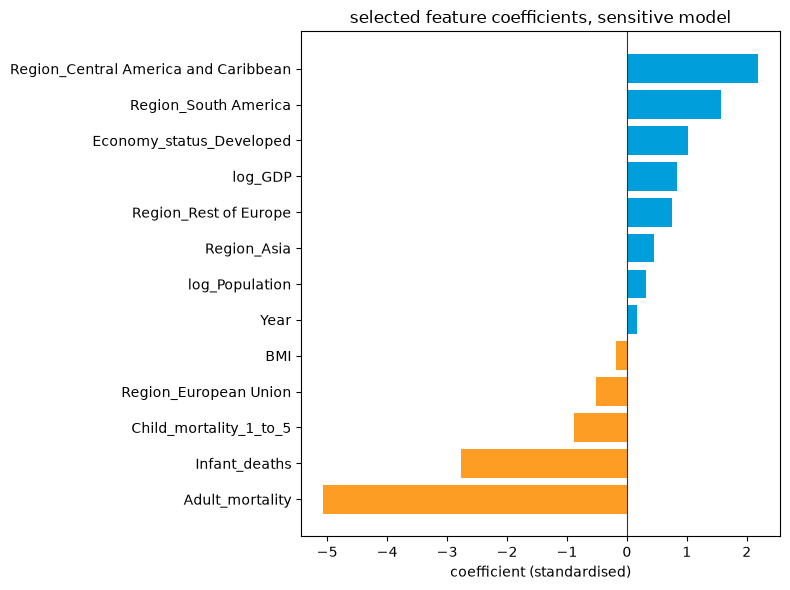

In [32]:
coef_df = pd.DataFrame({'feature': clean_names, 'coefficient': best_model.coef_}).sort_values('coefficient')
colors = [WHO_GOLD if c < 0 else WHO_BLUE for c in coef_df['coefficient']]

plt.figure(figsize=(8, 6))
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='#333333', linewidth=0.8)
plt.xlabel('coefficient (standardised)')
plt.title('selected feature coefficients, sensitive model')
plt.tight_layout()
plt.show()

### Choosing the Number of Features

`n_features_to_select=13` was passed to the sequential feature selector, but is this the best value? The chart below refits the selector for every feature count from 1 to 20 and plots the cross-validated MSE at each step, to see if 13 sits at a reasonable elbow rather than being an arbitrary choice.

_Note,_ this cell fits 100 models (ranging from 1 to 20 features) so it is slow to run.

  - run once
  - `cv_scores` are saved as a json file
  - plot from that going forward 
  - no more re-running the expensive loop

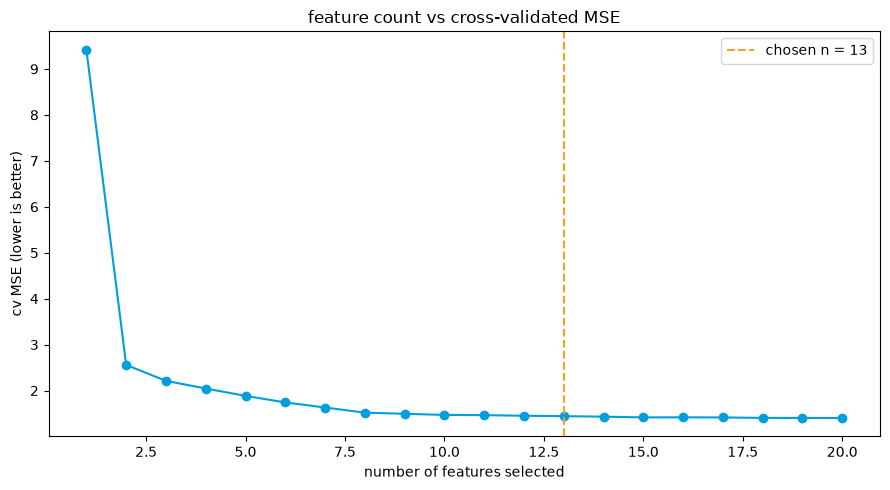

In [33]:
from sklearn.model_selection import cross_val_score
import json

CACHE_PATH = 'cv_scores_cache.json'
feature_range = range(1, 21)

try:
    with open(CACHE_PATH) as f:
        cv_scores = json.load(f)
except FileNotFoundError:
    cv_scores = []
    for n in feature_range:
        temp_selector = SequentialFeatureSelector(
            estimator=LinearRegression(),
            n_features_to_select=n,
            direction="forward",
            scoring="neg_mean_squared_error",
            cv=5,
            n_jobs=-1
        )
        temp_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('feature_selection', temp_selector),
            ('model', LinearRegression())
        ])
        scores = cross_val_score(temp_pipeline, X_sensitive_train, y_sensitive_train, cv=5, scoring='neg_mean_squared_error')
        cv_scores.append(-scores.mean())

    with open(CACHE_PATH, 'w') as f:
        json.dump(cv_scores, f)

plt.figure(figsize=(9, 5))
plt.plot(list(feature_range), cv_scores, marker='o', color=WHO_BLUE)
plt.axvline(13, color=WHO_GOLD, linestyle='--', label='chosen n = 13')
plt.xlabel('number of features selected')
plt.ylabel('cv MSE (lower is better)')
plt.title('feature count vs cross-validated MSE')
plt.legend()
plt.tight_layout()
plt.show()

## Residual Analysis

To verify a linear regression model is appropriate to model this data, we can perform some simple checks:

1. Confirm the mean of the residuals is approx. 0
2. Visualize the residuals and confirm a homoscedastic relationship

In [34]:
predictions = pipeline.predict(X_sensitive_test)

comparison = pd.DataFrame({'actual_value': y_sensitive_test, 'prediction': predictions})
comparison['residuals'] = comparison['actual_value'] - comparison['prediction']
comparison.sample(10)

,actual_value,prediction,residuals
1117,79.8,79.736478,0.063522
2501,53.0,50.481596,2.518404
2601,70.6,70.027233,0.572767
1027,73.2,72.783851,0.416149
1236,44.4,42.513000,1.887000
962,73.2,73.090064,0.109936
1025,70.9,71.138286,-0.238286
1577,55.8,56.925778,-1.125778
246,72.5,72.327444,0.172556
612,75.7,75.091829,0.608171


In [35]:
residuals_mean = np.mean(comparison['residuals']) # verify mean of residuals is approx. zero - assumptions of linreg is not violated
residuals_mean

np.float64(0.006773377725056325)

### Homoscedasticity Check

Residuals are plotted against the model's fitted (predicted) values rather than actual vs prediction. This isolates whether the spread of errors changes as predictions increase.

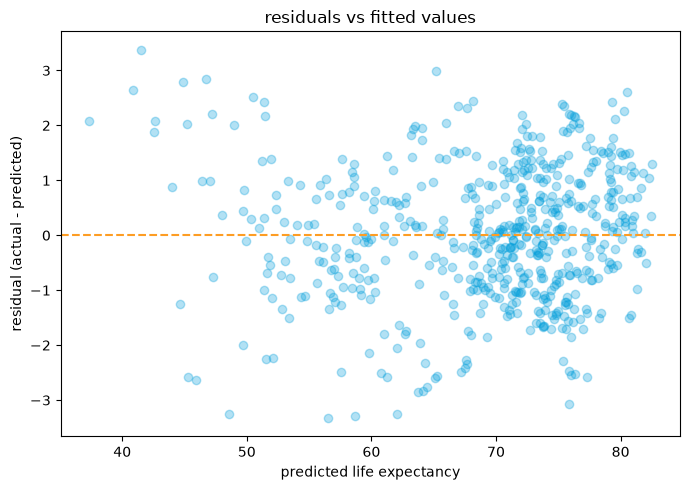

In [36]:
plt.figure(figsize=(7,5))
plt.scatter(comparison['prediction'], comparison['residuals'], alpha=0.3, color=WHO_BLUE)
plt.axhline(0, color=WHO_GOLD, linestyle='--')
plt.xlabel('predicted life expectancy')
plt.ylabel('residual (actual - predicted)')
plt.title('residuals vs fitted values')
plt.tight_layout()
plt.show()

Residuals plot shows a homoscedastic pattern, which aligns with the assumptions of a linear regression.

### Predicted vs Actual

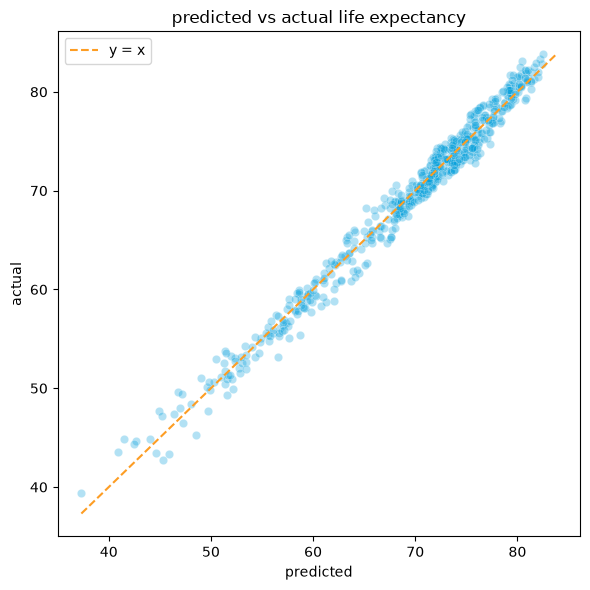

In [37]:
plt.figure(figsize=(6,6))
sns.scatterplot(data=comparison, x='prediction', y='actual_value', alpha=0.3, color=WHO_BLUE)
lims = [comparison[['prediction','actual_value']].min().min(), comparison[['prediction','actual_value']].max().max()]
plt.plot(lims, lims, color=WHO_GOLD, linestyle='--', label='y = x')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('predicted vs actual life expectancy')
plt.legend()
plt.tight_layout()
plt.show()

### Normality Check

So far we have only checked that the residual mean is close to zero. This section adds a check for normality using a residual histogram and a QQ plot, since normally distributed residuals are another assumption of linear regression.

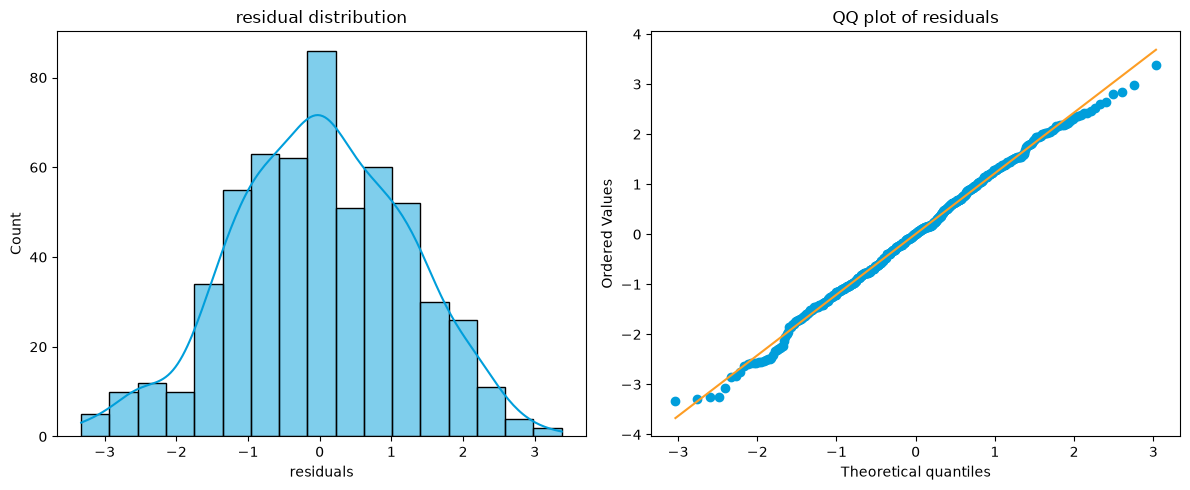

In [38]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(comparison['residuals'], kde=True, ax=axes[0], color=WHO_BLUE)
axes[0].set_title('residual distribution')
stats.probplot(comparison['residuals'], dist='norm', plot=axes[1])
axes[1].get_lines()[0].set_color(WHO_BLUE)
axes[1].get_lines()[1].set_color(WHO_GOLD)
axes[1].set_title('QQ plot of residuals')
plt.tight_layout()
plt.show()

---

### Evaluating the Initial Pipeline Model

In [39]:
from sklearn.metrics import (root_mean_squared_error,
                             r2_score)

def adj_r2_score(y_true, y_pred, n_features):
  
  r2 = r2_score(y_true, y_pred)
  n = len(y_true)
  
  adjusted_r2 = 1 - ((1-r2) * (n-1) / (n-n_features-1))
  return adjusted_r2

In [40]:
train_adj_r2 = adj_r2_score(y_sensitive_train, pipeline.predict(X_sensitive_train), n_features=len(pipeline.named_steps['model'].coef_))
test_adj_r2 = adj_r2_score(y_sensitive_test, pipeline.predict(X_sensitive_test), n_features=len(pipeline.named_steps['model'].coef_))

train_rmse = root_mean_squared_error(y_sensitive_train, pipeline.predict(X_sensitive_train))
test_rmse = root_mean_squared_error(y_sensitive_test, pipeline.predict(X_sensitive_test))

print(f'''Train
      
RMSE: {train_rmse:.3f}
Adj. R2: {train_adj_r2:.3f}

=====================

Test

RMSE: {test_rmse:.3f}
Adj. R2: {test_adj_r2:.3f}''')

Train

RMSE: 1.182
Adj. R2: 0.984


Test

RMSE: 1.209
Adj. R2: 0.982


* For our sensitive model, the test adjusted $R^{2}$ is 0.982 indicating around **98% of the variance** in life expectancy is explained by the model. This suggests a strong model predictive performance.

* The test RMSE comes out at 1.209, meaning a typical prediction is only **±1.209 years off of the true value**.

>This demonstrates the accuracy of our elaborate model is strong, but we **also want good interpretability**. We can achieve this by using as few features as possible that still retain a minimal RMSE.

## Hand-picked Feature Sets for Both Models

Optimised minimal feature sets have been identified for both models. 

>**We made a deliberate choice to use as few features as possible. This not only helps us with model interpretation, but also means that fewer sensitive features are required for the elaborate model.**

1. **Minimal** (no health related features)

* `region` (8 dummy features)
* `year`
* `log_GDP`
* `log_Population`

2. **Elaborate** (includes some sensitive health features)

* `region` (8 dummy features)
* `GDP_per_capita`
* `Adult_mortality`
* `Under_five_deaths`
* `Economy_status_Developed`

The results of the two models are displayed by the function below:

### Why these features rather than what our pipeline identified?

The sequential feature selector above (cells 43-51) settled on 13 columns via forward selection over the entire sensitive pool. The final models below instead use a smaller, manually chosen feature set. 

**Minimal pool, RMSE Trace**

| step | group added | rmse | change |
|---|---|---|---|
| 1 | `log_GDP` | 5.698 | — |
| 2 | `Region` | 4.510 | −1.19 |
| 3 | `Year` | 4.340 | −0.17 |
| 4 | `Economy_status` | 4.328 | −0.01 |
| 5 | `Schooling` | 4.325 | −0.003 |
| 6 | `Population_mln` | 4.324 | −0.0009 |

`log_GDP` and `Region` together account for almost the entire improvement, everything after is diminishing returns, so `Population_mln` and `Schooling` were dropped from the deployed minimal model.

**Elaborate pool, RMSE Trace**

| step | group added | rmse | change |
|---|---|---|---|
| 1 | `Adult_mortality` | 3.069 | — |
| 2 | `Under_five_deaths` | 1.704 | −1.37 |
| 3 | `Economy_status` | 1.477 | −0.23 |
| 4 | `Region` | 1.287 | −0.19 |
| 5 | `log_GDP` | 1.244 | −0.04 |
| 6 | `Year` | 1.235 | −0.009 |
| 7+ | `BMI`, `Schooling`, `Incidents_HIV`, immunisation, thinness | 1.211 | −0.024 combined |


* The first four groups take RMSE from 3.07 to 1.29, **comfortably beating the WHO baseline of 1.8**. 

* The remaining eight sensitive features combined only improve RMSE by a further 0.024 years.

Therefore, the decision was made for the deployed elaborate model  to keep `Region`, `GDP_per_capita`, `Adult_mortality`, `Under_five_deaths`, and `Economy_status_Developed`, dropping the remaining sensitive features since they cost almost nothing in accuracy while reducing how much sensitive data the model actually needs.

## Our Final Models

1. **Minimal Model** (no sensitive features)

$$
\text{Life expectancy} = 62.10 + (1.29\cdot\text{Year}) + (5.09\cdot\text{logGDP}) + (0.45\cdot\text{logPopulation}) + (8.94\cdot\text{RegionAsia}) + \text{Other region terms}
$$

* Train RMSE: 4.252
* Train Adj. $R^{2}$: 0.798

* Test RMSE: 4.542
* Test Adj. $R^{2}$: 0.747

* Residuals mean: 0.20

* Weaker Homoscedastic Residual Pattern

>Residual Analysis suggests the features used to train the minimal model do not entirely align with the assumptions of a linear model. This is expected however since our pool of usable features is restricted and there are signs of non-linear relationships between the target and features (e.g., GDP and Life expectancy).
>
>Nevertheless, the minimal model achieves a moderate level of success, with an adjusted $R^{2}$ of 0.747 on the test set, indicating a moderately well fitted regression line. The test RMSE error is 4.542, indicating that a typical prediction is ±4.54 years from the true life expectancy. 
>
>The similarity of the train and test error indicates the model is generalising fairly well - no indication of overfitting. If anything, the model shows signs of _underfitting_ since the test error is around 0.3 larger than the training error. The model is likely too simplistic.

---
2. **Elaborate Model** (contains sensitive features)

$$
\text{Life expectancy} = 68.63 + (0.46\cdot\text{GDP}) - (5.10\cdot\text{AdultMortality}) - (3.85\cdot\text{UnderFiveDeaths}) + (1.21\cdot\text{DevelopedEconomy}) + \text{Region terms}
$$

* Train RMSE: 1.244
* Train Adj. $R^{2}$: 0.983

* Test RMSE: 1.251
* Test Adj. $R^{2}$: 0.981

* Residuals mean: -0.001

* Homoscedastic Residual Pattern

>Residual Analysis demonstrates the data used to train the final elaborate model aligns more closely to the assumptions of a linear model when compared to the minimal model.
>
>The performance of the model is significantly improved relative to the minimal model, with an adjusted $R^{2}$ of 0.981 on the test set, indicating a strongly fitted regression line to unseen data. The test RMSE error is 1.251, indicating that a typical prediction is ±1.25 years from the true life expectancy. This still exceeds the WHO baseline value of 1.8 performing similarly with the original pipeline model.
>
>Additionally, the train and test error for the elaborate model is highly similar, meaning the model is generalising to unseen data very well - no indication of overfitting or underfitting.

### Model Interpretation

The coefficients above come from a pipeline that standardises every numeric feature before fitting, so each one reflects the effect of a one standard deviation change in that feature, not a raw per-unit change. Region coefficients are the exception, since `Region` is one-hot encoded rather than scaled, so those are already real, unscaled effects.

**Minimal model**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `Year` | +1.29 | a one standard deviation increase in year (~4.7 years of calendar time) is associated with about 1.29 more years of life expectancy |
| `log_GDP` | +5.09 | since GDP is log-transformed, a one standard deviation increase in log-GDP is associated with about 5.09 more years of life expectancy |
| `log_Population` | +0.45 | a one standard deviation increase in log-population is associated with a much smaller effect, about 0.45 years |
| `Region` (e.g. Asia) | +8.94 | being in Asia rather than the reference region is associated with about 8.9 more years, holding the other features constant |

**Elaborate model**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `Adult_mortality` | −5.10 | a one standard deviation increase in adult mortality (~116 deaths per 1,000) is associated with about 5.1 fewer years |
| `Under_five_deaths` | −3.85 | a one standard deviation increase (~45 deaths per 1,000 births) is associated with about 3.85 fewer years |
| `GDP_per_capita` | +0.46 | a one standard deviation increase (~$17,240) is associated with about 0.46 more years |
| `Economy_status_Developed` | +1.21 | a one standard deviation shift on this flag is associated with about 1.21 more years, being a 0/1 flag scaled like the continuous features, this reflects a standard deviation change rather than the flag switching from 0 to 1 outright |

`Adult_mortality` and `Under_five_deaths` are clearly carrying most of the elaborate model's accuracy, which lines up with the reconciliation note above, these are also the two most sensitive features in the pool.